# Proyecto 4: Machine Learning Explicable (XAI) - Modelado

En este cuaderno entrenamos un modelo de regresión para predecir el valor de las viviendas, que servirá como base para los análisis de explicabilidad.

## 1. Librerías y Carga de Datos

In [5]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Cargar datos del cuaderno anterior
df = pd.read_csv('../data/BostonHousing.csv')
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 2. Preparación de los Datos

Separamos en características (X) y objetivo (y).

In [6]:
X = df.drop('medv', axis=1)
y = df['medv']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")

Entrenamiento: (404, 13)
Prueba: (102, 13)


## 3. Entrenamiento del Modelo (Random Forest)

Utilizamos un bosque aleatorio para capturar relaciones no lineales entre las variables.

In [7]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


## 4. Evaluación del Modelo

In [8]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 2.8110
R2 Score: 0.8923


## 5. Importancia de Características (Feature Importance Tradicional)

La importancia integrada en Scikit-learn basada en la disminución de la impureza de Gini.

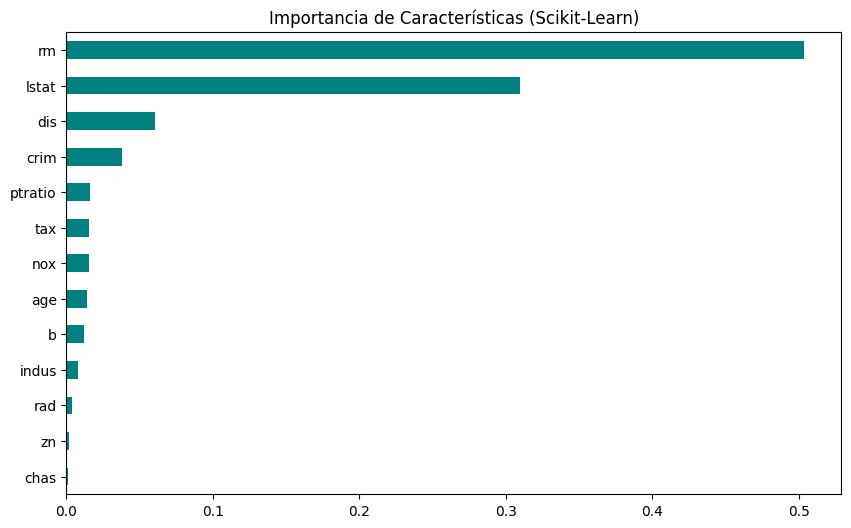

In [9]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh', color='teal')
plt.title('Importancia de Características (Scikit-Learn)')
plt.gca().invert_yaxis()
plt.show()

## 6. Guardar Modelo y Datos

Guardamos estos elementos para usarlos en los cuadernos de SHAP y LIME.

In [10]:
if not os.path.exists('../models'):
    os.makedirs('../models')

joblib.dump(model, '../models/random_forest_boston.pkl')
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

print("Modelo y datos guardados.")

Modelo y datos guardados.
